# Least squares with SGD

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import urllib
from pathlib import Path
import tarfile
import pandas as pd
import seaborn as sns
import hashlib
import scipy

In [2]:
import matplotlib as mpl
mpl.rcParams['axes.grid'] = True  # Use per default a grid, i.e. plt.grid()
# mpl.rcParams['figure.figsize'] = [6.4, 4.8]  # Change the default figure size

- `Tab`: Code completion or indent
- `Shift-Tab`: Tooltip
- `Shift-Tab Shift+Tab`: Long tooltip
- `Ctrl-Enter`: Run selected cells
- `Shift-Enter`: Run cell, select below
- `Alt-Enter`: Run cell and insert below
- `Ctrl-#`: Comment
- `Esc a`: New cell above
- `Esc b`: New cell below
- `Esc d d`: Delete current cell
- `Esc m`: Turn current cell into Markdown cell
- `Esc y`: Turn current cell into code cell

# Download the California household prices dataset

- Each row contains data about a block group (600 to 3000 people)
- Some values are missing/ clipped or scaled.

Values in the dataset:
1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea

Inspect the dataset and discuss what the `pairplot` shows.
Does it help to decide, which features might be good to predict `median_house_value`?

For those that use `cocalc.com`:
If you do not have internet access in your Jupyter notebook, you need to download the `housing.tgz` manually and then upload it to your environment just as you uploaded the notebook file.

In [3]:
csv_path = Path('housing.csv')

if not csv_path.is_file():
    remote_url = 'https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.tgz'
    local_path = Path('housing.tgz')

    if not local_path.is_file():
        urllib.request.urlretrieve(remote_url, local_path)

    with tarfile.open(local_path) as f:
        f.extractall()

In [4]:
df = pd.read_csv(csv_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


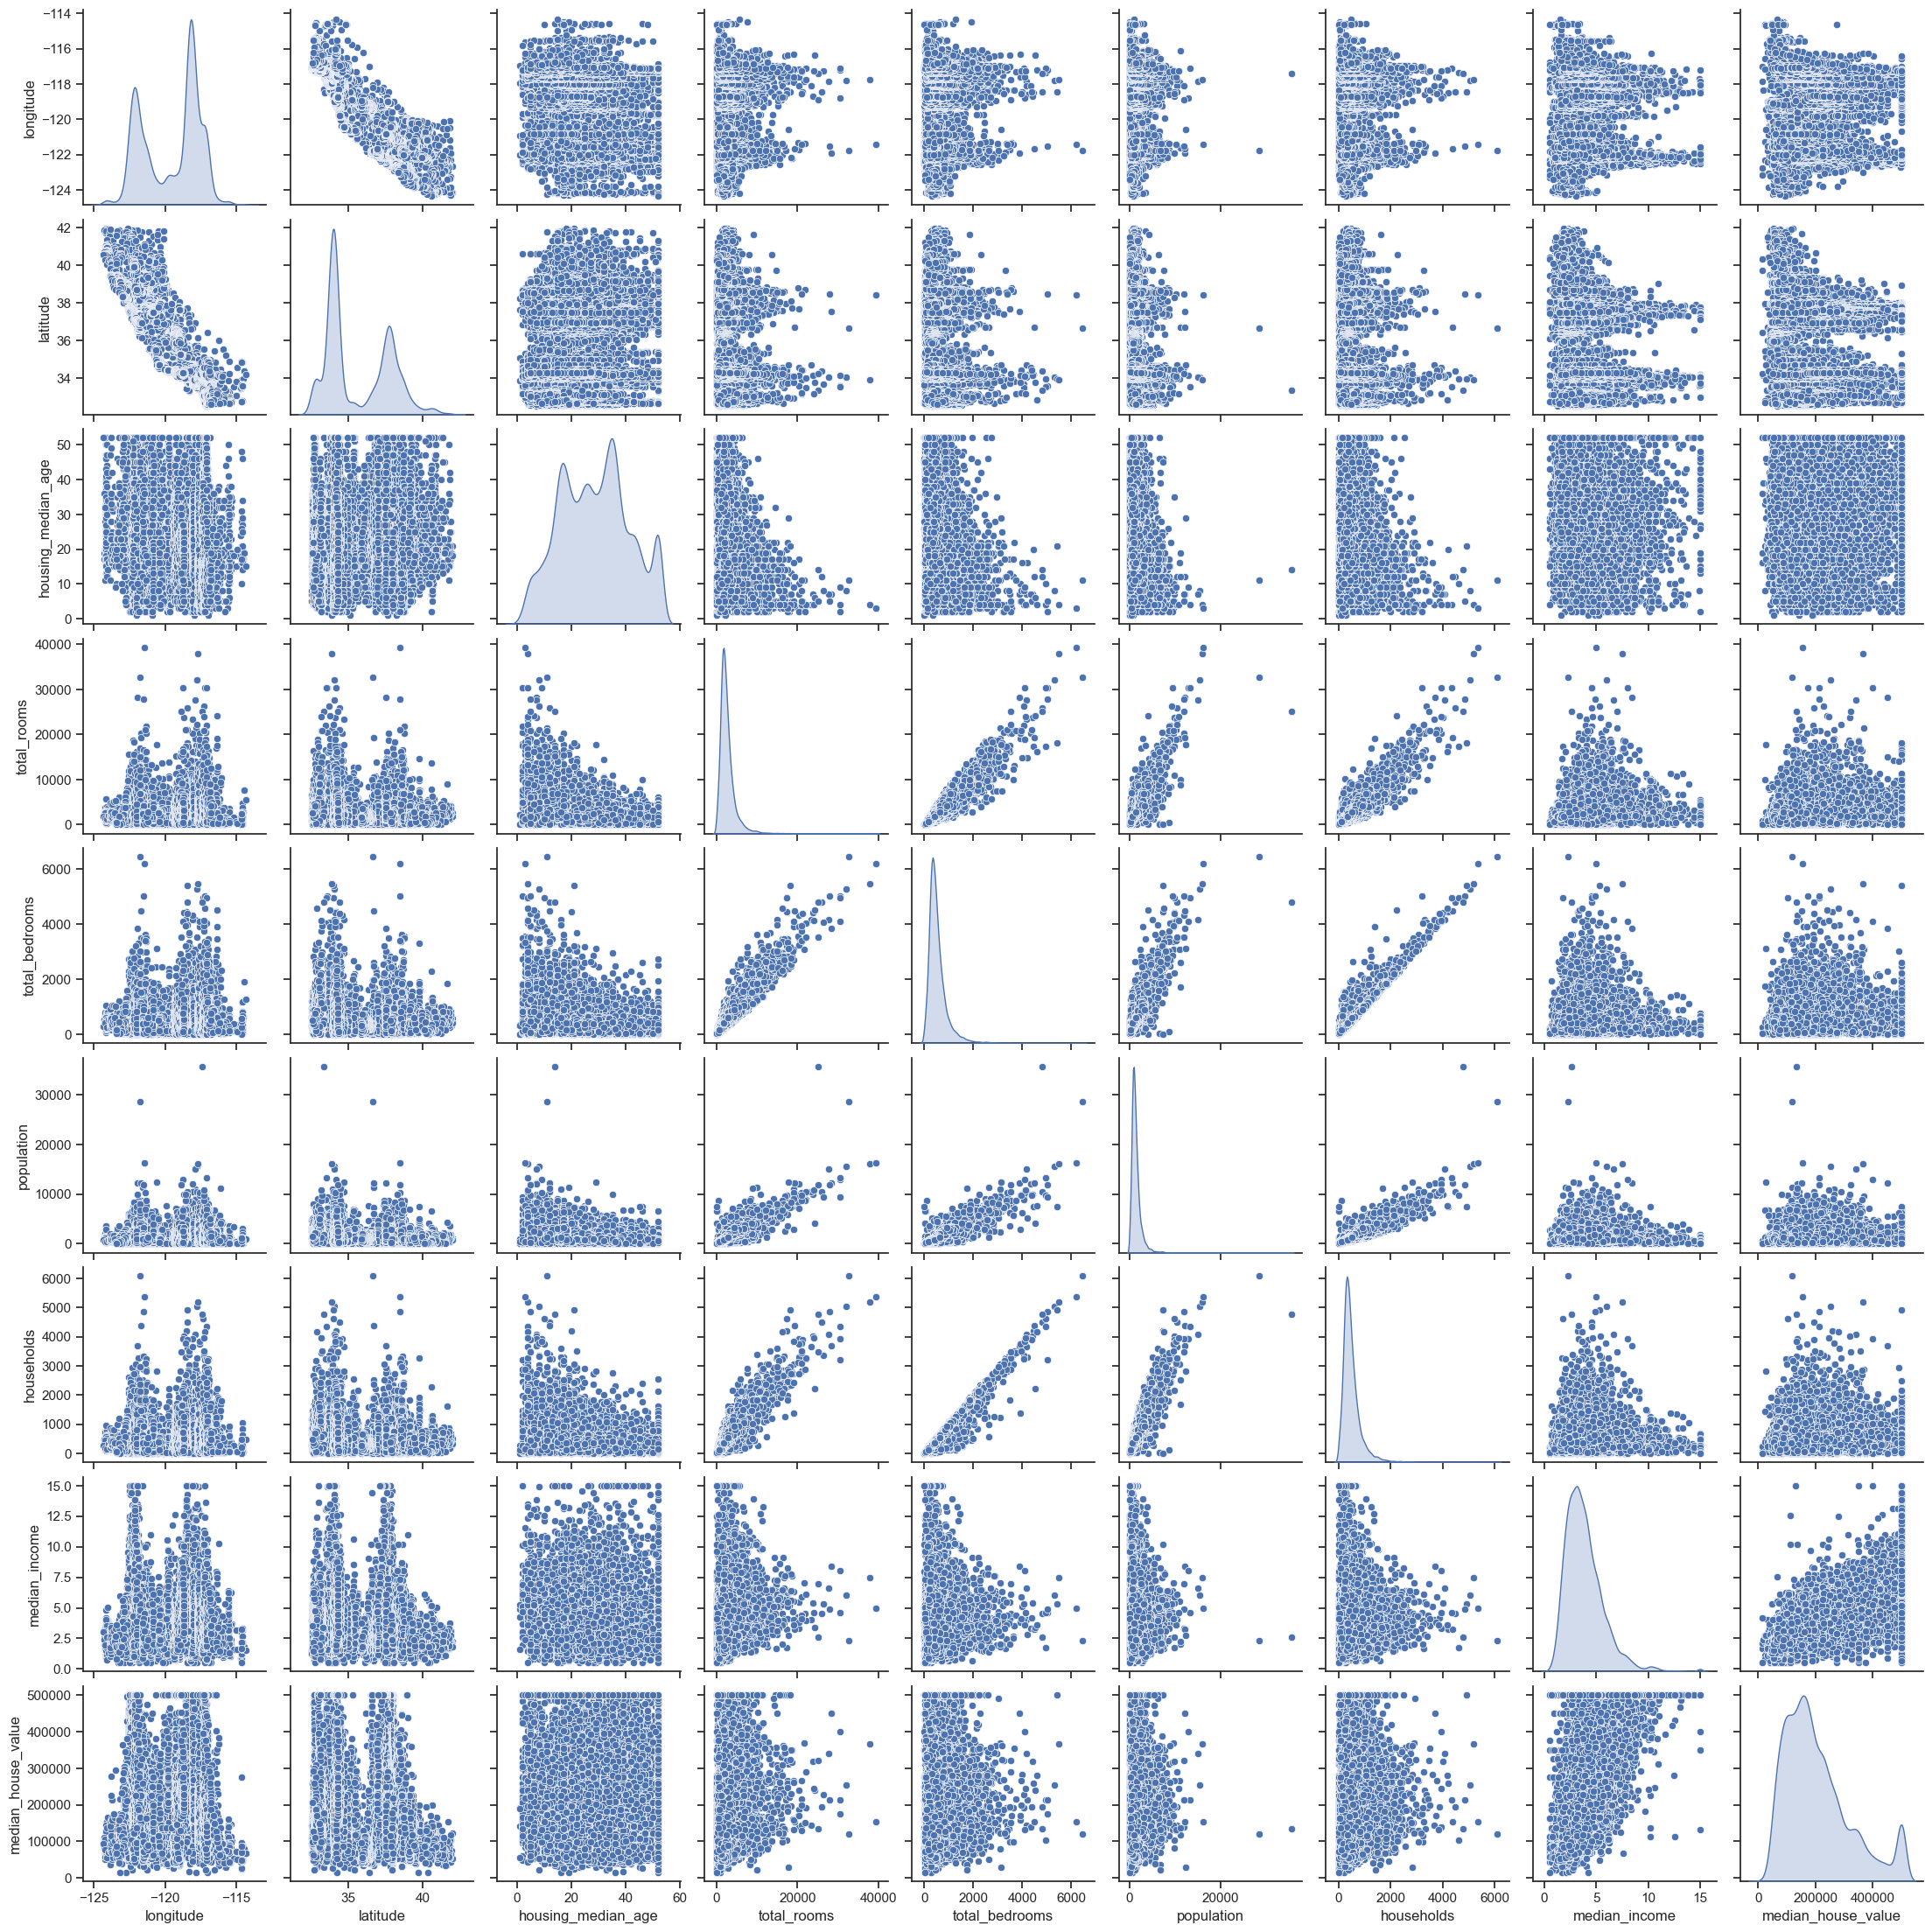

In [8]:
# Check https://seaborn.pydata.org/examples/index.html
sns.set(style="ticks")
pair_plot = sns.pairplot(df.dropna(), diag_kind='kde')  # Using kde instead of hist
plt.show()

Data interpretation: The figure above shows correlation between features. the diagonal represents auto-correlation

# Remove missing data and clipped data

When data is missing or is corrupted, you basically have three options:
- Drop the row (i.e. the record cotaining the missing value)
- Drop the column (i.e. drop the complete feature)
- Fill with a sane default value (often median of the train set, has to be stored for the test conditions later)

In [9]:
# Drops all rows which contain NaN anywhere
df = df.dropna()

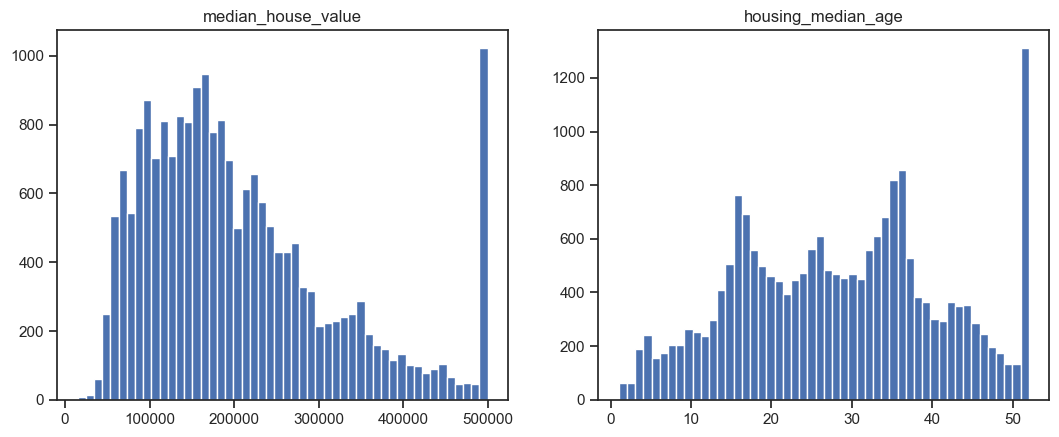

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(6.4 * 2, 4.8))
for ax, feature in zip(axes, ['median_house_value', 'housing_median_age']):
    ax.hist(df[feature], bins=50)
    ax.set_title(feature)
plt.show()

In [11]:
# Are there corrupted values?
df['median_house_value'].max(), df['housing_median_age'].max()

(500001.0, 52.0)

In [12]:
# Filter out outliers for median_house_value
q1_house = df['median_house_value'].quantile(0.25)
q3_house = df['median_house_value'].quantile(0.75)
iqr_house = q3_house - q1_house
df = df.query('@q1_house - 1.5*@iqr_house <= median_house_value <= @q3_house + 1.5*@iqr_house')

# Filter out outliers for housing_median_age
q1_age = df['housing_median_age'].quantile(0.25)
q3_age = df['housing_median_age'].quantile(0.75)
iqr_age = q3_age - q1_age
df = df.query('@q1_age - 1.5*@iqr_age <= housing_median_age <= @q3_age + 1.5*@iqr_age')

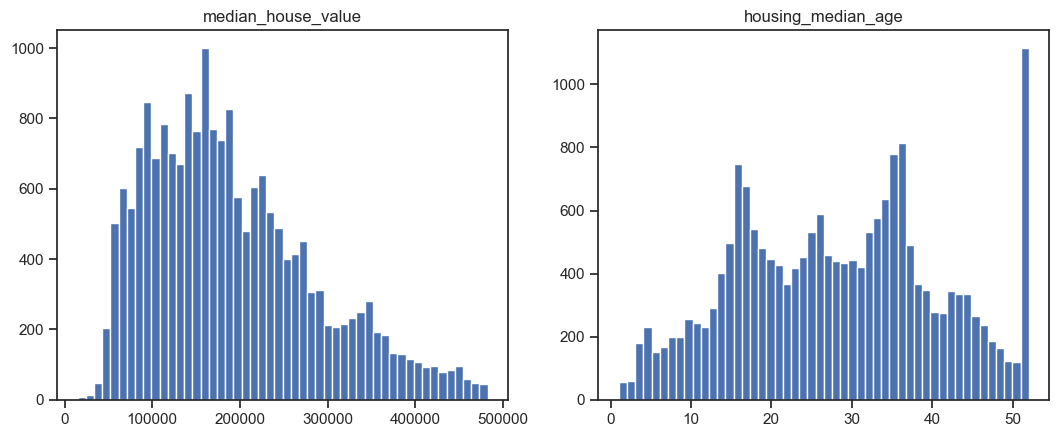

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(6.4*2, 4.8))
for ax, feature in zip(axes, ['median_house_value', 'housing_median_age']):
    ax.hist(df[feature], bins=50)
    ax.set_title(feature)
plt.show()

# Split dataset into subsets

It is absolutely crutial to split the dataset into at least two subsets:
- Train set
- Test set

Often, people tend to split the dataset into three different subsets:
- Train set
- Cross-validation set/ Validation set
- Test set

You would then train on the train set and always check how your algorithm performs on the CV set.
Just for the final results you would run your model once on the test set but not change any parameters afterwards anymore.
The best model has to be selected based on the CV set.

In [14]:
df['_id'] = df.apply(lambda row: '{}_{}'.format(
    row["longitude"],
    row["latitude"]
), axis=1)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,_id
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,-122.23_37.88
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,-122.22_37.86
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,-122.24_37.85
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,-122.25_37.85
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122.25_37.85


In [15]:
def is_in_test_set(key, test_ratio):
    hash_value = hashlib.md5(key.encode()).digest()
    return hash_value[-1] < 256 * test_ratio

def split_train_test(dataframe, test_ratio):
    in_test_set = dataframe._id.apply(lambda _id: is_in_test_set(_id, test_ratio))
    return dataframe.loc[~in_test_set], dataframe.loc[in_test_set]

df_train, df_test = split_train_test(df, 0.2)

In [16]:
print('df:       {}'.format(len(df)))
print('df_train: {}'.format(len(df_train)))
print('df_test:  {}'.format(len(df_test)))

df:       19369
df_train: 15577
df_test:  3792


# Model the median house value based on median income

Fit the ordinary least squares model to predict median house values based on median income.

$y_n = w_0 + w_1 x_n + v_n$ with $v_n \sim \mathcal{N}(0, \sigma_v^2)$

### Matrix notation:
The objective can be written as $J =  \lVert\mathbf{y} - \mathbf{X}\boldsymbol{\theta}\rVert^2$ with 

 - Observation matrix: $\mathbf{X} = \begin{bmatrix} 1 & x_{11} & \dots & x_{1D} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{N1} & \dots & x_{ND} \end{bmatrix} \in \mathbb{R}^{N \times D} = \mathbb{R}^{14744 \times 2}$
 - Target vector $\mathbf{y} = \begin{bmatrix}y_1\\\vdots\\y_N\end{bmatrix}$
 - Parameter vector $\boldsymbol{\theta} = \begin{bmatrix}w_0\\\vdots\\w_{D}\end{bmatrix}$
 
After some simple steps (Try it, it is important to be able to optimize such an objective) we obtain $\boldsymbol{\theta} = (\mathbf{X}^\mathrm{T} \mathbf{X})^{-1} \mathbf{X}^\mathrm{T}\mathbf{y}$

#### steps:

Solution Steps:

Model Setup: 
Linear regression model: $y_n = w_0 + w_1 x_n + v_n$

$y_n$: median house value

$x_n$: median income

$v_n \sim \mathcal{N}(0, \sigma_v^2)$

Matrix Form:

$\mathbf{y} = \mathbf{X}\boldsymbol{\theta} + \mathbf{v}$

$\mathbf{X} = \begin{bmatrix} 1 & x_1 \\ \vdots & \vdots \\ 1 & x_N \end{bmatrix}$

$\boldsymbol{\theta} = \begin{bmatrix} w_0 \ w_1 \end{bmatrix}$

Objective:

Minimize $J = \lVert \mathbf{y} - \mathbf{X}\boldsymbol{\theta} \rVert^2$

Solution:

$\nabla J = -2\mathbf{X}^\mathrm{T}\mathbf{y} + 2\mathbf{X}^\mathrm{T}\mathbf{X}\boldsymbol{\theta} = 0$

$\boldsymbol{\theta} = (\mathbf{X}^\mathrm{T}\mathbf{X})^{-1}\mathbf{X}^\mathrm{T}\mathbf{y}$



### Questions:
 - The start equation is a polynom with order 1.
   It is easy to see, that this is a linear classifier.
   When we increase the polynom order $y_n = w_0 + w_1 x_n + \dots + w_D x_n^D + v_n$, would it be still a linear classifier?
 - Why is there a column of ones in the observation matrix?

In [17]:
y = np.asarray(df_train.median_house_value)
y.shape

(15577,)

In [18]:
y

array([452600., 358500., 352100., ...,  92300.,  84700.,  89400.])

In [19]:
X = np.stack([np.ones_like(df_train.median_income), df_train.median_income], axis=-1)
print(X[:5, :])
X.shape

[[1.     8.3252]
 [1.     8.3014]
 [1.     7.2574]
 [1.     2.0804]
 [1.     3.2031]]


(15577, 2)

In [20]:
%timeit theta = np.linalg.pinv(X) @ y  
%timeit theta, _, _, _ = scipy.linalg.lstsq(X, y)  
%timeit theta = np.linalg.solve(X.T @ X, X.T @ y)
theta = np.linalg.solve(X.T @ X, X.T @ y)
theta

318 μs ± 28.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
156 μs ± 3.57 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
74.6 μs ± 1.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


array([46536.40931873, 39634.92944763])

Plot the training and test data and the regression model.

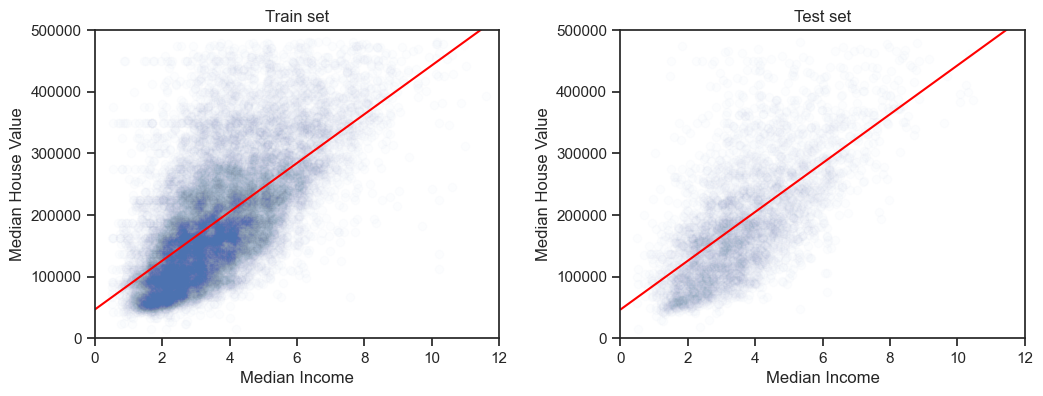

In [21]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3) 
def partial_plot(ax, dataframe, title, theta):
    ax.scatter(dataframe.median_income, dataframe.median_house_value, alpha=0.01)
    x_plot = np.linspace(0, 12, 100)  # 100 points from 0 to 12
    # For linear model: y = w1*x + w0
    y_plot = theta[0] + theta[1] * x_plot
    ax.plot(x_plot, y_plot, color='red')
    ax.set_title(title)
    ax.set_xlim((0, 12))
    ax.set_ylim((0, 500000))
    ax.set_xlabel('Median Income')
    ax.set_ylabel('Median House Value')
    

partial_plot(axes[0], df_train, 'Train set', theta)
partial_plot(axes[1], df_test, 'Test set', theta)
plt.show()

Calculate the root mean squared error of your predictions both on the train and on the test set.

In [22]:
y_test = np.asarray(df_test.median_house_value)
y_test.shape

(3792,)

In [23]:
X_test = np.stack([df_test.median_income, np.ones_like(df_test.median_income)], axis=-1)
X_test.shape

(3792, 2)

In [24]:
def root_mean_squared_error(X, y, theta):
    difference = y - X @ theta  # Calculate prediction errors
    assert difference.shape == (X.shape[0],), 'Unexpected shape: {}'.format(difference.shape)
    return np.sqrt(np.mean(difference**2))  # Square root of mean squared errors

%timeit root_mean_squared_error(X, y, theta)
root_mean_squared_error(X, y, theta)  

41 μs ± 2.75 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


73539.35169121246

In [25]:
# Check your root_mean_squared_error implementation with a toy example
rmse = root_mean_squared_error(
    X=np.array([
        [1, 2],
        [1, 3],
        [1, 4],
    ]),
    y=np.array([10, 12, 14]),
    theta=np.array([6, 2])
)
assert rmse == 0, rmse

In [26]:
X.shape, y.shape, theta.shape

((15577, 2), (15577,), (2,))

In [27]:
print('Train error: {:10.0f} US$'.format(
    root_mean_squared_error(X, y, theta)
))

print('Test error:  {:10.0f} US$'.format(
    root_mean_squared_error(X_test, y_test, theta)
))

Train error:      73539 US$
Test error:       75106 US$


# Stochastic gradient descent

Implement a (stochastic) gradient descent algorithm to estimate the linear regression parameters.
Ideally, write a function which allows to set different parameter, e.g. mini batch size.
Add some kind of learning rate schedule (i.e. learning rate decreases by a factor of 10 after each epoch after the 5th).

Functions you may want to use:
 - `np.random.shuffle`
 - `np.array_split`

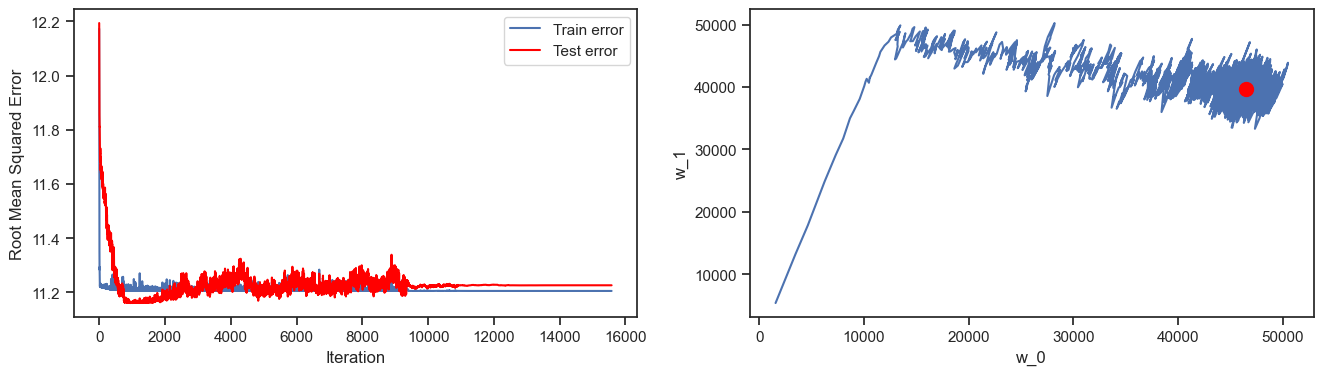

Best test loss:      70331


In [28]:
def get_learning_rate(epoch):
    # This is a fixed learning rate schedule.
    initial_learning_rate = 0.01  
    if epoch <= 5:
        return initial_learning_rate  
    else:  
        return initial_learning_rate * 10 ** -(epoch - 5)  

def get_gradient_theta(X, y, theta):
    batch_size = X.shape[0] 
    return -(X.T @ y - X.T @ X @ theta) / batch_size  

def fit(X_train, y_train, X_test, y_test, epochs=10, batch_size=10, logging=True):
    number_of_examples, number_of_parameters = X_train.shape
    
    # Set up batching parameters
    all_example_indices = list(range(number_of_examples))
    number_of_batches = -(-number_of_examples // batch_size)
    
    # Initialize variables
    theta = np.zeros(number_of_parameters)
    
    # Prepare logging
    if logging:
        train_error_history = []
        test_error_history = []
        theta_history = []
    else:
        train_error_history = None
        test_error_history = None
        theta_history = None
    
    for epoch in range(epochs):
        learning_rate = get_learning_rate(epoch)
        np.random.shuffle(all_example_indices)  # REPLACE ???  # shuffle all_example_indices
        
        for mini_batch in np.array_split(all_example_indices, number_of_batches):  # REPLACE ???  # for mini_batch in ???:
            gradient = get_gradient_theta(  # REPLACE ???
                X_train[mini_batch, :],  # REPLACE
                y_train[mini_batch],  # REPLACE
                theta  # REPLACE
            )  # REPLACE
            theta = theta - learning_rate * gradient  # REPLACE
            
            if logging:
                theta_history.append(theta)
                train_error_history.append(
                    root_mean_squared_error(X_train, y_train, theta)
                )
                test_error_history.append(
                    root_mean_squared_error(X_test, y_test, theta)
                )
    
    if logging:
        train_error_history = np.asarray(train_error_history)
        test_error_history = np.asarray(test_error_history)
        theta_history = np.asarray(theta_history)
    
    return theta, train_error_history, test_error_history, theta_history

theta, train_error_history, test_error_history, theta_history = fit(
    X, y,
    X_test, y_test,
    epochs=10,
    batch_size=10,
    logging=True
)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.plot(np.log(train_error_history), label='Train error')
ax.plot(np.log(test_error_history), color='red', label='Test error')
ax.set_xlabel('Iteration')
ax.set_ylabel('Root Mean Squared Error')
ax.legend()

ax = axes[1]
ax.plot(theta_history[:, 0], theta_history[:, 1])
ax.scatter(theta[0], theta[1], color='red', zorder=3, s=100)
ax.set_xlabel('w_0')
ax.set_ylabel('w_1')

plt.show()
print('Best test loss: {:10.0f}'.format(np.min(test_error_history)))

In [29]:
theta_history.shape

(15580, 2)

In [30]:
%%timeit  
theta, train_error_history, test_error_history, theta_history = fit(
    X, y,  
    X_test, y_test,  
    epochs=10,  
    batch_size=10,  
    logging=False 
)  

371 ms ± 38.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [31]:
%%timeit  
theta, train_error_history, test_error_history, theta_history = fit( 
    X, y,  
    X_test, y_test,  
    epochs=10,  
    batch_size=10,  
    logging=True  
)  

1.59 s ± 41.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# For experts...

- Check the somewhat famous paper [1] from Yoshua Bengio. Especially Section 2 is worth a read. Also Section 3.1.1 provides useful information about learning rate schedules and other hyper-parameters.
- Implement early stopping (stop when CV loss does not decrease for a few epochs).
- Implement learning rate back-off based on CV loss.

You can also add more features from the dataset to try to predict the prices better.
How would you use the `ocean_proximity` feature.

- [1] https://arxiv.org/pdf/1206.5533.pdf

### One complte run (to understand the theory behind iteration):

In [32]:
import numpy as np
x = np.array([[1,2], [1,4]])
y_gt = np.array([4, 6])
theta = np.array([1.001, 1.003])
#prediction
y = np.matmul(x , theta)
print(y)
#error
error = y - y_gt
print("error: ", error)
#mse
print("mse: ",((error[0])**2 + error[1]**2)/2)
#gradient
grad = np.matmul(x, y) - np.matmul(np.matmul(x, x.T), theta)
print("grad: ", grad)
#new theta
LR = 0.001
new_theta = theta - LR * grad
print("new theta: ", new_theta)

[3.007 5.013]
error:  [-0.993 -0.987]
mse:  0.9801090000000003
grad:  [-0.999 -3.001]
new theta:  [1.001999 1.006001]


In [33]:
0.3**2

0.09

### Let's try to run in the loop & converge

In [45]:
import numpy as np

# Initialize data and parameters
x = np.array([[1,2], [1,4]])
y_gt = np.array([4, 6])
theta = np.array([1.001, 1.003])
LR = 0.01
epochs = 100000  # You can adjust this number

print(f"Initial theta: {theta}")

for epoch in range(epochs):
    # Prediction
    y = np.matmul(x, theta)
    
    # Error
    error = y - y_gt
    
    # MSE
    mse = ((error[0])**2 + error[1]**2)/2
    
    # Gradient
    grad = np.matmul(x.T, y - y_gt) / len(y_gt)
    
    # Update theta
    theta = theta - LR * grad
    
    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"\nEpoch {epoch + 1}:")
        print(f"  MSE: {mse}")
        print(f"  Theta: {theta}")
        print(f"  Grad: {grad}")

print("\nFinal theta:", theta)

Initial theta: [1.001 1.003]

Epoch 100:
  MSE: 0.0700169998787016
  Theta: [1.16432652 1.25301869]
  Grad: [-0.07668878  0.02318418]

Epoch 200:
  MSE: 0.058282845333957944
  Theta: [1.23756148 1.23084781]
  Grad: [-0.06995923  0.02118195]

Epoch 300:
  MSE: 0.04851521874956866
  Theta: [1.30437777 1.21061747]
  Grad: [-0.06382835  0.01932567]

Epoch 400:
  MSE: 0.040384549464456826
  Theta: [1.36533861 1.19216001]
  Grad: [-0.05823475  0.01763206]

Epoch 500:
  MSE: 0.03361649967746788
  Theta: [1.42095715 1.17532007]
  Grad: [-0.05313135  0.01608688]

Epoch 600:
  MSE: 0.027982707880888684
  Theta: [1.47170156 1.1599559 ]
  Grad: [-0.04847519  0.01467711]

Epoch 700:
  MSE: 0.023293083689852324
  Theta: [1.51799899 1.14593816]
  Grad: [-0.04422706  0.01339088]

Epoch 800:
  MSE: 0.0193893939818819
  Theta: [1.56023914 1.13314888]
  Grad: [-0.04035123  0.01221737]

Epoch 900:
  MSE: 0.01613992393580843
  Theta: [1.59877757 1.12148038]
  Grad: [-0.03681505  0.0111467 ]

Epoch 1000:
  

Initial theta: [1.001 1.003]

Epoch 100:
  MSE: 0.18459402794762142
  Theta: [1.06468178 1.1831888 ]

Epoch 200:
  MSE: 0.09234124784175349
  Theta: [1.09143821 1.24169652]

Epoch 300:
  MSE: 0.08075053531122231
  Theta: [1.10581408 1.25958652]

Epoch 400:
  MSE: 0.07817803935576931
  Theta: [1.11600606 1.26392812]

Epoch 500:
  MSE: 0.07663440995705471
  Theta: [1.12475171 1.2637604 ]

Epoch 600:
  MSE: 0.07522834177633417
  Theta: [1.13296565 1.26210165]

Epoch 700:
  MSE: 0.07386003157839885
  Theta: [1.14095371 1.25995963]

Epoch 800:
  MSE: 0.07251794311296549
  Theta: [1.14881849 1.25767072]

Epoch 900:
  MSE: 0.07120039007529502
  Theta: [1.15659467 1.25534713]

Epoch 1000:
  MSE: 0.06990679178197431
  Theta: [1.16429426 1.25302618]

Epoch 1100:
  MSE: 0.06863669796983111
  Theta: [1.17192171 1.25072021]

Epoch 1200:
  MSE: 0.06738967992282681
  Theta: [1.17947893 1.24843321]

Epoch 1300:
  MSE: 0.06616531820449174
  Theta: [1.18696697 1.2461664 ]

Epoch 1400:
  MSE: 0.064963201

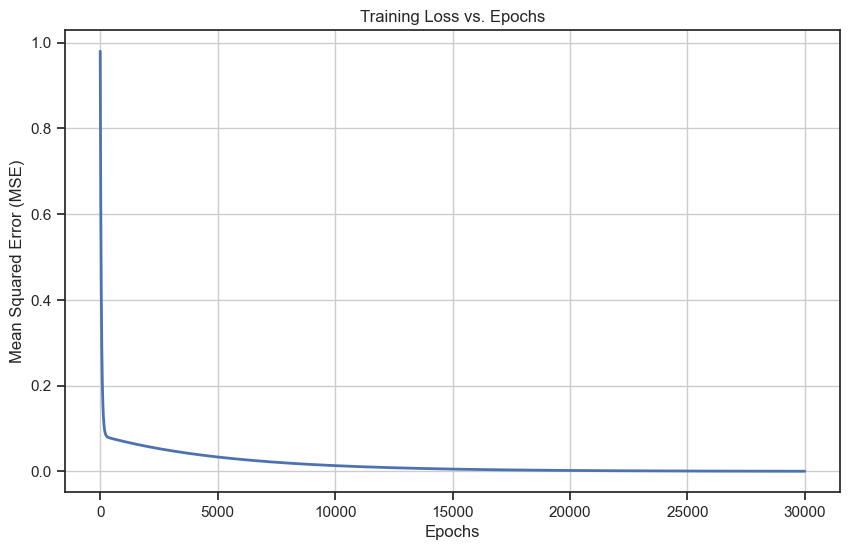


Final theta: [1.9414645  1.01772312]
Final MSE: 0.00034296737281414296


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize data and parameters
x = np.array([[1,2], [1,4]])
y_gt = np.array([4, 6])
theta = np.array([1.001, 1.003])
LR = 0.001
epochs = 30000

# Lists to store loss and epoch values
loss_history = []
epoch_list = []

print(f"Initial theta: {theta}")

for epoch in range(epochs):
    # Prediction
    y = np.matmul(x, theta)
    
    # Error
    error = y - y_gt
    
    # MSE
    mse = ((error[0])**2 + error[1]**2)/2
    loss_history.append(mse)
    epoch_list.append(epoch)
    
    # Gradient
    grad = np.matmul(x.T, y - y_gt) / len(y_gt)
    
    # Update theta
    theta = theta - LR * grad

        # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"\nEpoch {epoch + 1}:")
        print(f"  MSE: {mse}")
        print(f"  Theta: {theta}")

# Plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(epoch_list, loss_history, 'b-', linewidth=2)
plt.title('Training Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

print("\nFinal theta:", theta)
print("Final MSE:", loss_history[-1])

### Implement early stopping (stop when CV loss does not decrease for a few epochs).

Initial theta: [1.001 1.003]
Epoch 100: MSE = 0.184594
Epoch 200: MSE = 0.092341
Epoch 300: MSE = 0.080751
Epoch 400: MSE = 0.078178
Epoch 500: MSE = 0.076634
Epoch 600: MSE = 0.075228
Epoch 700: MSE = 0.073860
Epoch 800: MSE = 0.072518
Epoch 900: MSE = 0.071200
Epoch 1000: MSE = 0.069907
Epoch 1100: MSE = 0.068637
Epoch 1200: MSE = 0.067390
Epoch 1300: MSE = 0.066165
Epoch 1400: MSE = 0.064963
Epoch 1500: MSE = 0.063783
Epoch 1600: MSE = 0.062624
Epoch 1700: MSE = 0.061486
Epoch 1800: MSE = 0.060369
Epoch 1900: MSE = 0.059272
Epoch 2000: MSE = 0.058196
Epoch 2100: MSE = 0.057138
Epoch 2200: MSE = 0.056100
Epoch 2300: MSE = 0.055081
Epoch 2400: MSE = 0.054080
Epoch 2500: MSE = 0.053098
Epoch 2600: MSE = 0.052133
Epoch 2700: MSE = 0.051186
Epoch 2800: MSE = 0.050256
Epoch 2900: MSE = 0.049343
Epoch 3000: MSE = 0.048446
Epoch 3100: MSE = 0.047566
Epoch 3200: MSE = 0.046702
Epoch 3300: MSE = 0.045853
Epoch 3400: MSE = 0.045020
Epoch 3500: MSE = 0.044202
Epoch 3600: MSE = 0.043399
Epoch 37

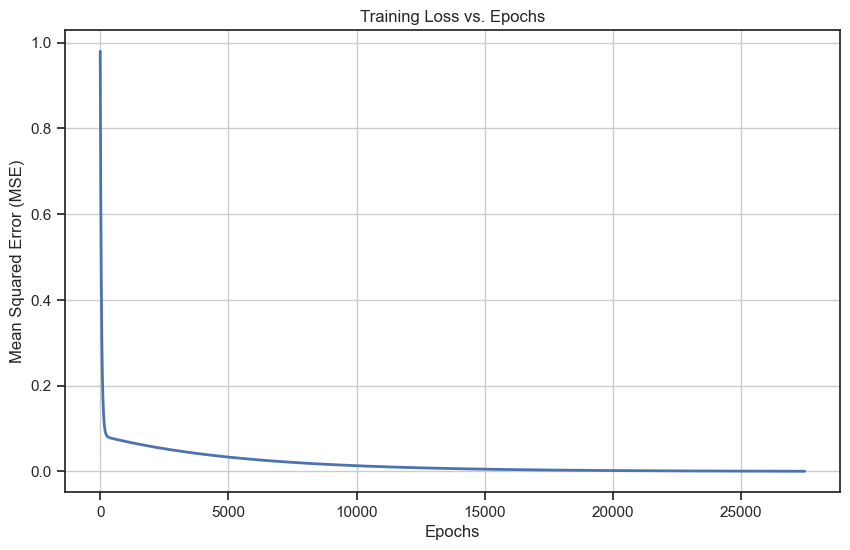


Best theta: [1.92620419 1.02234357]
Best MSE: 0.0005450017381214845


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize data and parameters
x = np.array([[1,2], [1,4]])
y_gt = np.array([4, 6])
theta = np.array([1.001, 1.003])
LR = 0.001
max_epochs = 30000
patience = 10  # Number of epochs to wait before stopping if no improvement
min_delta = 1e-6  # Minimum change in loss to qualify as improvement

# Lists to store loss and epoch values
loss_history = []
best_loss = float('inf')
no_improve_epochs = 0

print(f"Initial theta: {theta}")

for epoch in range(max_epochs):
    # Prediction
    y = np.matmul(x, theta)
    
    # Error
    error = y - y_gt
    
    # MSE
    mse = np.mean(error ** 2)
    loss_history.append(mse)
    
    # Early stopping check
    if mse < best_loss - min_delta:
        best_loss = mse
        best_theta = theta.copy()
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print(f"\nEarly stopping at epoch {epoch + 1}")
            print(f"Best MSE: {best_loss:.6f}")
            break
    
    # Gradient
    grad = np.matmul(x.T, error) / len(y_gt)
    
    # Update theta
    theta = theta - LR * grad
    
    # Print progress
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}: MSE = {mse:.6f}")

# Plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_history)), loss_history, 'b-', linewidth=2)
plt.title('Training Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

print("\nBest theta:", best_theta)
print("Best MSE:", best_loss)

### Implement learning rate back-off based on CV loss.

Learning rate back-off is a technique that reduces the learning rate when the model's performance on a validation set stops improving. This helps the model converge more effectively by taking smaller steps when it's close to the minimum.

Initial theta: [1.001 1.003]
Initial learning rate: 0.001
Epoch 100: MSE = 0.184594, LR = 0.001000
Epoch 200: MSE = 0.092341, LR = 0.001000
Epoch 300: MSE = 0.080751, LR = 0.001000
Epoch 400: MSE = 0.078178, LR = 0.001000
Epoch 500: MSE = 0.076634, LR = 0.001000
Epoch 600: MSE = 0.075228, LR = 0.001000
Epoch 700: MSE = 0.073860, LR = 0.001000
Epoch 800: MSE = 0.072518, LR = 0.001000
Epoch 900: MSE = 0.071200, LR = 0.001000
Epoch 1000: MSE = 0.069907, LR = 0.001000
Epoch 1100: MSE = 0.068637, LR = 0.001000
Epoch 1200: MSE = 0.067390, LR = 0.001000
Epoch 1300: MSE = 0.066165, LR = 0.001000
Epoch 1400: MSE = 0.064963, LR = 0.001000
Epoch 1500: MSE = 0.063783, LR = 0.001000
Epoch 1600: MSE = 0.062624, LR = 0.001000
Epoch 1700: MSE = 0.061486, LR = 0.001000
Epoch 1800: MSE = 0.060369, LR = 0.001000
Epoch 1900: MSE = 0.059272, LR = 0.001000
Epoch 2000: MSE = 0.058196, LR = 0.001000
Epoch 2100: MSE = 0.057138, LR = 0.001000
Epoch 2200: MSE = 0.056100, LR = 0.001000
Epoch 2300: MSE = 0.055081,

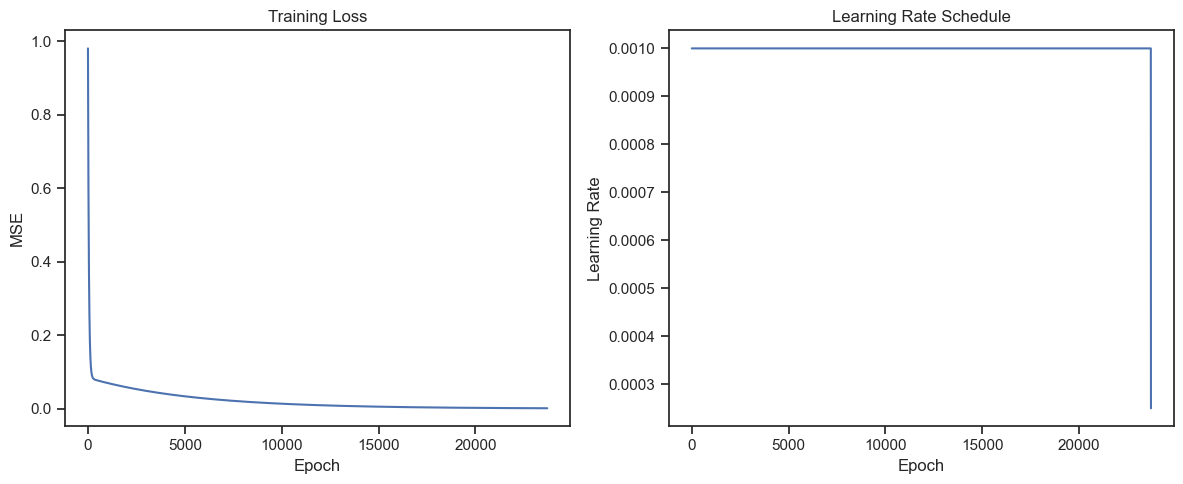


Best theta: [1.89566437 1.03159029]
Best MSE: 0.0010894310916011749


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize data and parameters
x = np.array([[1,2], [1,4]])
y_gt = np.array([4, 6])
theta = np.array([1.001, 1.003])
initial_lr = 0.001
max_epochs = 30000
patience = 10
min_delta = 1e-6

# For learning rate back-off
lr = initial_lr
lr_patience = 5  # Epochs to wait before reducing LR
lr_factor = 0.5   # Factor by which to reduce the learning rate
min_lr = 1e-6     # Minimum learning rate

# For early stopping
best_loss = float('inf')
no_improve_epochs = 0
no_lr_improve_epochs = 0

# For plotting
loss_history = []
lr_history = []

print(f"Initial theta: {theta}")
print(f"Initial learning rate: {lr}")

for epoch in range(max_epochs):
    # Prediction
    y = np.matmul(x, theta)
    
    # Error and MSE
    error = y - y_gt
    mse = np.mean(error ** 2)
    loss_history.append(mse)
    lr_history.append(lr)
    
    # Check for improvement
    if mse < best_loss - min_delta:
        best_loss = mse
        best_theta = theta.copy()
        no_improve_epochs = 0
        no_lr_improve_epochs = 0
    else:
        no_improve_epochs += 1
        no_lr_improve_epochs += 1
    
    # Learning rate back-off
    if no_lr_improve_epochs >= lr_patience:
        new_lr = max(lr * lr_factor, min_lr)
        if new_lr < lr:
            print(f"\nReducing learning rate from {lr:.6f} to {new_lr:.6f}")
            lr = new_lr
            no_lr_improve_epochs = 0  # Reset counter
    
    # Early stopping
    if no_improve_epochs >= patience:
        print(f"\nEarly stopping at epoch {epoch + 1}")
        print(f"Best MSE: {best_loss:.6f}")
        break
    
    # Gradient and update
    grad = np.matmul(x.T, error) / len(y_gt)
    theta = theta - lr * grad
    
    # Print progress
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}: MSE = {mse:.6f}, LR = {lr:.6f}")

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')

plt.subplot(1, 2, 2)
plt.plot(lr_history)
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')

plt.tight_layout()
plt.show()

print("\nBest theta:", best_theta)
print("Best MSE:", best_loss)